In [2]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your project folder path
# Change 'CSCI592_FinalProject' to whatever you want your folder named
PROJECT_PATH = '/content/drive/My Drive/CSCI592_FinalProject'

# 3. Create the directory if it doesn't exist
if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"Created folder: {PROJECT_PATH}")
else:
    print(f"Folder already exists: {PROJECT_PATH}")

# 4. Set it as the current working directory
os.chdir(PROJECT_PATH)
print(f"Current Working Directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder already exists: /content/drive/My Drive/CSCI592_FinalProject
Current Working Directory: /content/drive/My Drive/CSCI592_FinalProject


In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuration
DATA_PATH = 'final_train.csv'
SEED = 42

In [4]:
# Load data
df = pd.read_csv(DATA_PATH)

# Check distribution
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

# Check a few examples
print("\nSample Data:")
print(df.head())

Dataset Shape: (1510, 2)

Class Distribution:
label
NEUTRAL_DISTRESS    549
ALL_OR_NOTHING      515
MIND_READING        446
Name: count, dtype: int64

Sample Data:
                                                text             label
0  я никогда не найду работу, я буду безработным ...    ALL_OR_NOTHING
1  my life is completely over if i don't pass thi...    ALL_OR_NOTHING
2                                i feel like crying.  NEUTRAL_DISTRESS
3                                        ішім пысты.  NEUTRAL_DISTRESS
4      every time i try to study, i fail completely.    ALL_OR_NOTHING


In [5]:
# 1. Split Data
X = df['text'].astype(str)
y = df['label']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Training Samples: 1208
Testing Samples: 302


In [6]:
# 2. Vectorization
# ngram_range=(1,2) captures phrases like "everyone thinks" (bigrams)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorization complete.")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Vectorization complete.
Vocabulary size: 10000


In [7]:
# 3. Train the SVM
# LinearSVC is generally faster and better for text than standard SVC
svm_model = LinearSVC(class_weight='balanced', random_state=SEED)
svm_model.fit(X_train_vec, y_train)

print("SVM Training Complete.")

SVM Training Complete.


=== SVM Classification Report ===
                  precision    recall  f1-score   support

  ALL_OR_NOTHING       0.87      0.80      0.83       103
    MIND_READING       0.94      0.87      0.90        89
NEUTRAL_DISTRESS       0.82      0.94      0.87       110

        accuracy                           0.87       302
       macro avg       0.88      0.87      0.87       302
    weighted avg       0.87      0.87      0.87       302



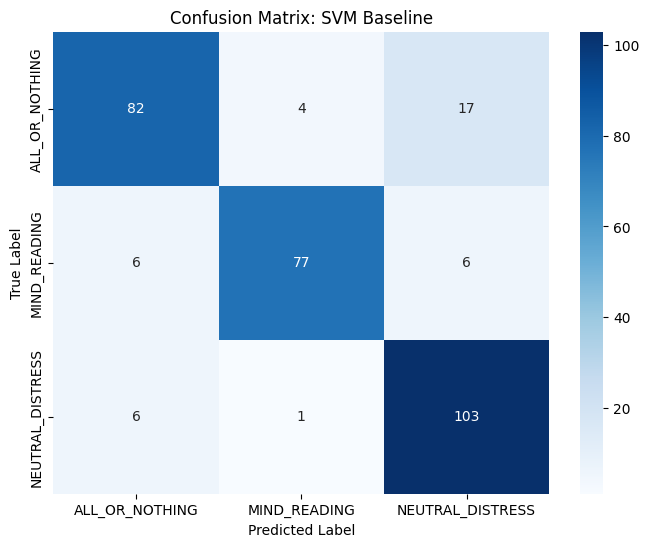

In [9]:
# 4. Predict
y_pred_svm = svm_model.predict(X_test_vec)

# 5. Text Report
print("=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title('Confusion Matrix: SVM Baseline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
# Save for the Inference Engine
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("SVM artifacts saved as 'vectorizer.pkl' and 'model.pkl'")

SVM artifacts saved as 'vectorizer.pkl' and 'model.pkl'


In [11]:
!pip install transformers datasets torch accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [8]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder

# 1. Encode Labels to Integers (BERT requires 0, 1, 2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Save the label encoder mapping for later use
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_map)

# 2. Tokenizer (Multilingual Cased is CRITICAL for Russian/Kazakh)
MODEL_NAME = 'distilbert-base-multilingual-cased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# 3. Tokenize Data
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

Label Mapping: {'ALL_OR_NOTHING': np.int64(0), 'MIND_READING': np.int64(1), 'NEUTRAL_DISTRESS': np.int64(2)}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [9]:
class DistortionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create Datasets
train_dataset = DistortionDataset(train_encodings, y_train_enc)
test_dataset = DistortionDataset(test_encodings, y_test_enc)

In [14]:
# 1. Load Model
model_bert = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# 2. Define Metrics Function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

# 3. Training Arguments
training_args = TrainingArguments(
    output_dir='./results',

    # Training Duration
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    # Hyperparameters for Small Data
    learning_rate=2e-5,               # Slower learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    weight_decay=0.1,                 # Higher regularization to prevent overfitting

    # Logging
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 5. Train
print("Starting Optimized Training...")
trainer.train()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Optimized Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.559600,0.555796,0.778146
2,0.327100,0.483379,0.814570
3,0.183600,0.500383,0.837748
4,0.079200,0.558116,0.857616
5,0.019200,0.692372,0.834437
6,0.011500,0.691083,0.847682
7,0.010700,0.762691,0.850993
8,0.002600,0.749301,0.860927
9,0.002700,0.738552,0.864238
10,0.002400,0.771748,0.850993


TrainOutput(global_step=760, training_loss=0.1556650076208538, metrics={'train_runtime': 402.3478, 'train_samples_per_second': 30.024, 'train_steps_per_second': 1.889, 'total_flos': 400058678292480.0, 'train_loss': 0.1556650076208538, 'epoch': 10.0})

In [15]:
# Evaluate
eval_result = trainer.evaluate()
print(f"DistilBERT Accuracy: {eval_result['eval_accuracy']:.4f}")

# Detailed Report
preds_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)

print("=== DistilBERT Classification Report ===")
print(classification_report(y_test_enc, y_pred_bert, target_names=le.classes_))

# Save BERT Model (Optional, takes space)
trainer.save_model("./bert_model_final")
tokenizer.save_pretrained("./bert_model_final")

DistilBERT Accuracy: 0.8146
=== DistilBERT Classification Report ===
                  precision    recall  f1-score   support

  ALL_OR_NOTHING       0.88      0.69      0.77       103
    MIND_READING       0.94      0.83      0.88        89
NEUTRAL_DISTRESS       0.71      0.92      0.80       110

        accuracy                           0.81       302
       macro avg       0.84      0.81      0.82       302
    weighted avg       0.83      0.81      0.81       302



('./bert_model_final/tokenizer_config.json',
 './bert_model_final/special_tokens_map.json',
 './bert_model_final/vocab.txt',
 './bert_model_final/added_tokens.json',
 './bert_model_final/tokenizer.json')